# Teste de Baseline com rede neural artificial para predição de resistência à compressão

In [1]:
%%capture
!pip install optuna

In [2]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão neural
rna_file = 'df_resistencia_MLP.pkl'
rna_path = os.path.join(dirpath, rna_file)

df_rna = pd.read_pickle(rna_path)
df_rna['target'] = df_rna['Resistencia_Compressao_MPa'].copy()
df_rna.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [5]:
n_groups = df_rna['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [6]:
X = df_rna.drop(
    columns=["target", "Autores/ano"]
)

y = df_rna["target"]
groups = df_rna["Autores/ano"]

def objective(trial):
    rmse_scores = []
    n_layers = trial.suggest_int('n_layers', 2, 3)

    layer1 = trial.suggest_int('layer1', 20, 80)

    layer2 = trial.suggest_int(
        'layer2',
        5,
        layer1
    )

    if n_layers == 2:
        hidden_layer_sizes = (
            layer1,
            layer2
        )
    else:
        layer3 = trial.suggest_int(
            'layer3',
            3,
            layer2
        )

        hidden_layer_sizes = (
            layer1,
            layer2,
            layer3
        )

    hyperparams = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': 'tanh',
        'solver': 'lbfgs',
        'alpha': trial.suggest_float(
            'alpha',
            350,
            650,
            log=True
        ),
        'max_iter': 9000,
        'random_state': 42
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = MLPRegressor(**hyperparams)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Hiperparâmetros", unit="trial")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_rna = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_rna.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_rna.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_rna.best_params.items():
    print(f"  '{key}': {value},") 

In [7]:
best_params = {
    'hidden_layer_sizes': (78, 76),
    'activation': "tanh",
    'solver': "lbfgs",
    'alpha': 377.38015153251644,
    'max_iter': 9000,
    'random_state': 42
}

In [8]:
all_preds = []
all_true = []
all_groups = []

X = df_rna.drop(
    columns=["target", "Autores/ano"]
)

y = df_rna["target"]
groups = df_rna["Autores/ano"]

for fold, (train_idx, val_idx) in tqdm(enumerate(
    gkf.split(X, y, groups)), total=len(list(gkf.split(X, y, groups))), desc="Executando Cross-Validation", unit="fold"):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = MLPRegressor(**best_params)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [9]:
mlp_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

mlp_results["residual"] = (
    mlp_results["y_true"] -
    mlp_results["y_pred"]
)

mlp_results["abs_error"] = (
    mlp_results["residual"].abs()
)

## Observado vs Predito

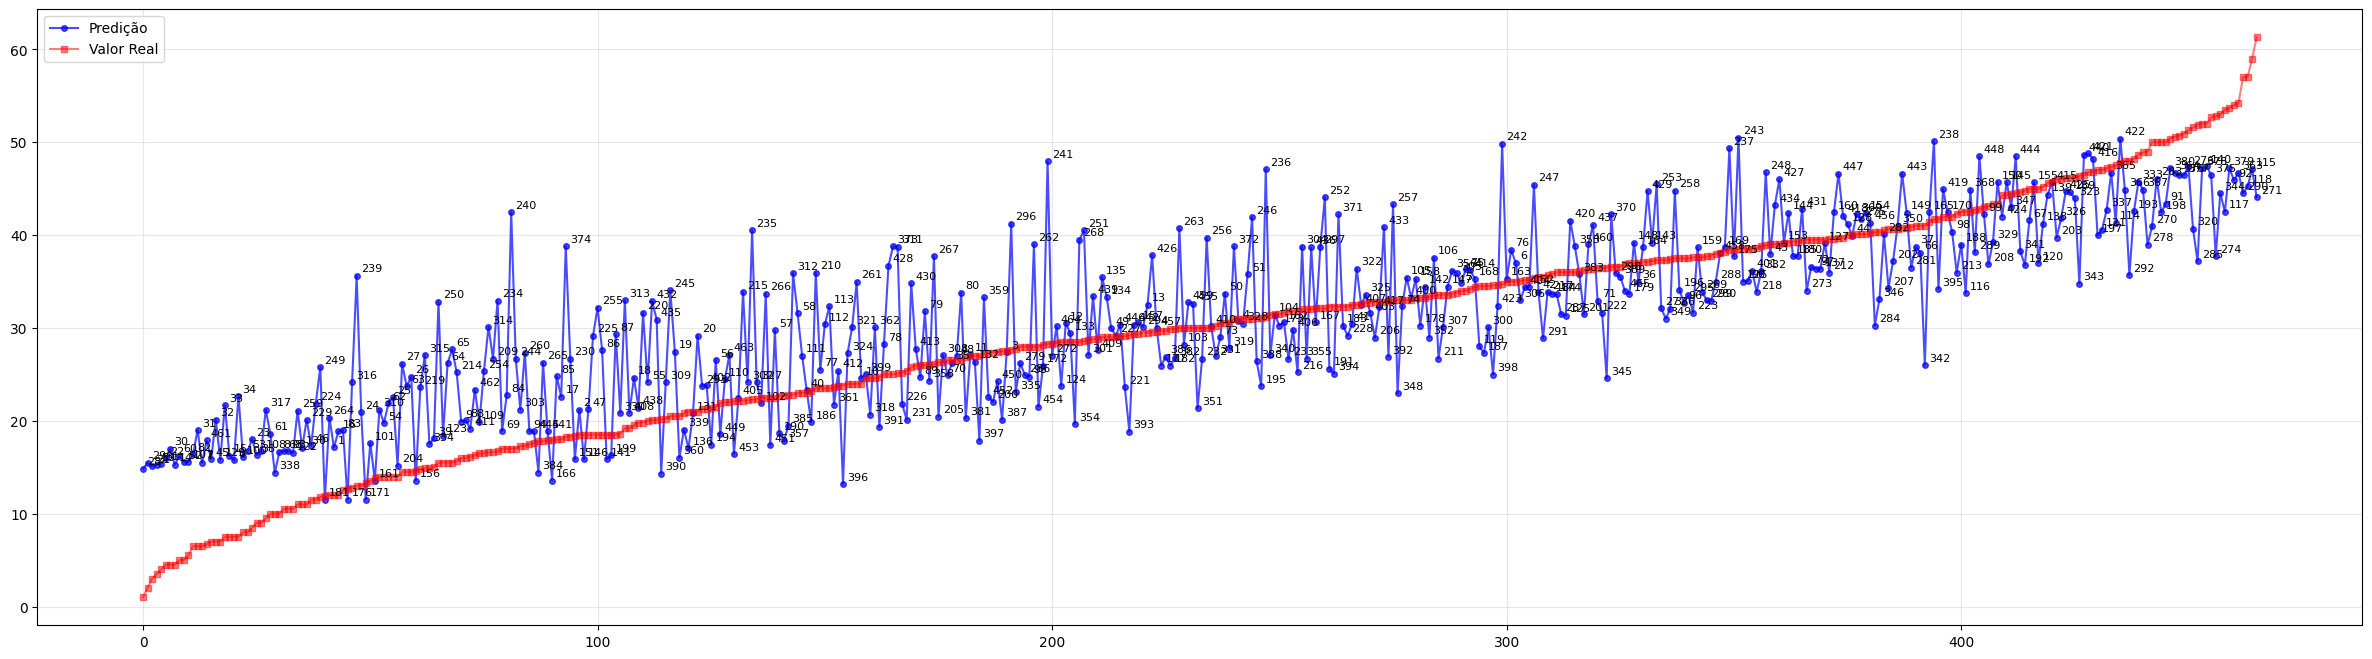

In [10]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = mlp_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

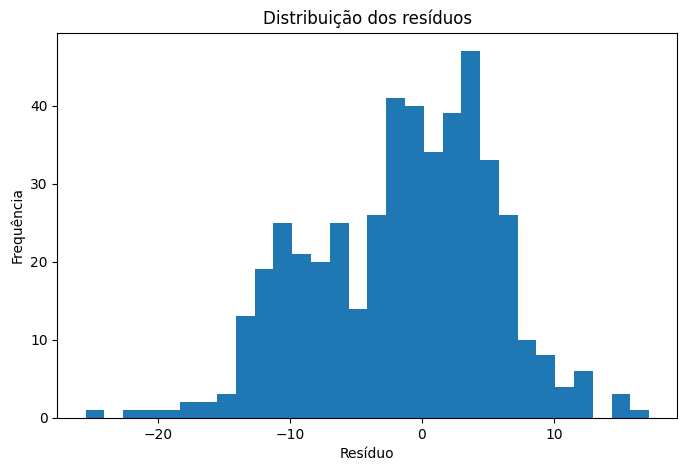

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    mlp_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

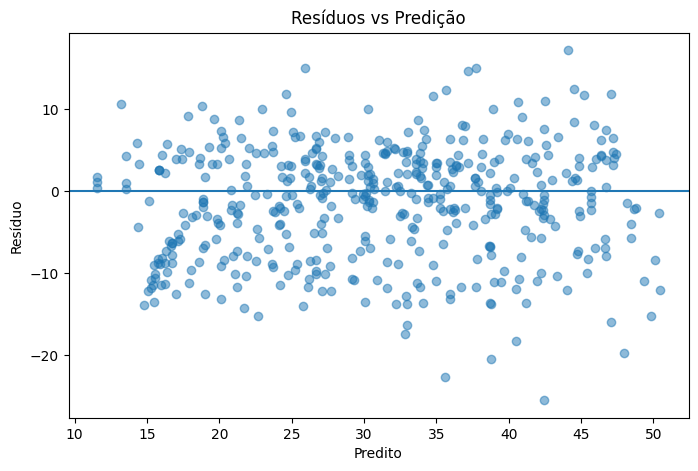

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    mlp_results["y_pred"],
    mlp_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

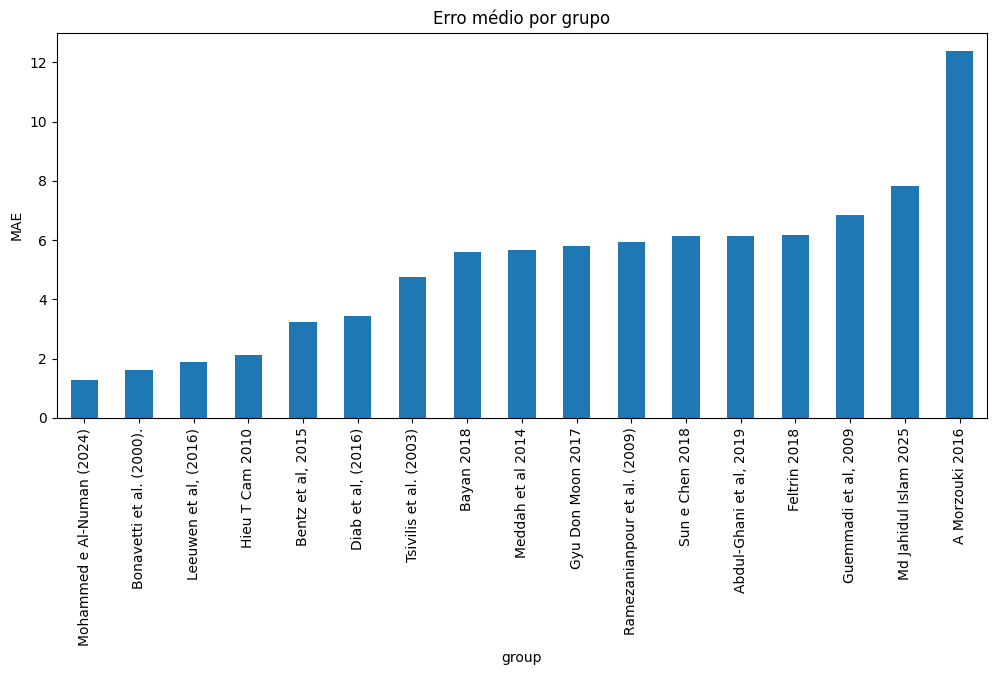

In [16]:
group_errors = (
    mlp_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [17]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 6.9893
mean_absolute_error: 5.5304
mean_absolute_percentage_error: 0.3436
R² Score: 66.9705


In [19]:
df_rna["Autores/ano"].unique()

array(['Guemmadi et al, 2009', 'Meddah et al 2014', 'A Morzouki 2016',
       'Bentz et al, 2015', 'Feltrin 2018', 'Gyu Don Moon 2017',
       'Hieu T Cam 2010', 'Md Jahidul Islam 2025', 'Diab et al, (2016)',
       'Mohammed e Al-Numan (2024)', 'Leeuwen et al, (2016)',
       'Ramezanianpour et al. (2009)', 'Bayan 2018',
       'Bonavetti et al. (2000).', 'Tsivilis et al. (2003)',
       'Sun e Chen 2018', 'Abdul-Ghani et al, 2019'], dtype=object)

In [25]:
display(df_rna.describe())

,Cimento_kg_m3,Filer_Calcario_kg_m3,Agregado_Graudo_Total_kg_m3,ln_Idade,Tipo_Molde_Cod,Metodo_Emp_Cod,D_Max,Massa_Esp_Cimento_kg_m3,Massa_Esp_Filer_kg_m3,porosidade_volumetrica_inicial,...,schiller_real,aci_209_fator_tempo,s_fib,fib_fator_tempo,fib_estimativa_base,vol_cimento,vol_filer,Relacao_Agua_Aglomerante,vol_sp,target
count,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,...,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000
mean,282.930687,62.608369,1082.328755,2.962788,3.036481,0.133047,19.510769,3152.133539,2712.142071,0.193237,...,0.947317,0.858342,0.251288,0.899227,0.996784,0.089716,0.023106,0.531545,0.000429,29.518798
std,66.922386,44.445702,138.062544,1.526574,1.361830,0.339991,2.707469,47.749679,68.559854,0.014979,...,0.099630,0.284070,0.041172,0.239315,0.466651,0.021038,0.016439,0.114126,0.000794,12.174431
min,129.300000,0.000000,732.400000,0.000000,1.000000,0.000000,12.500000,3040.000000,2550.000000,0.152572,...,0.715743,0.206186,0.200000,0.342024,0.068166,0.041178,0.000000,0.340000,0.000000,1.000000
25%,235.000000,32.000000,1018.000000,1.945910,2.000000,0.000000,19.000000,3140.000000,2700.000000,0.185000,...,0.903095,0.703518,0.250000,0.778801,0.640958,0.074841,0.011852,0.450000,0.000000,20.500000
50%,282.000000,60.000000,1058.000000,3.332205,4.000000,0.000000,19.294059,3148.041237,2700.000000,0.194000,...,0.960325,1.007194,0.250000,1.000000,0.959221,0.090282,0.022133,0.510000,0.000000,30.000000
75%,332.500000,97.000000,1200.000000,4.025352,4.000000,0.000000,20.000000,3190.909091,2710.000000,0.201000,...,1.011489,1.085271,0.250000,1.075971,1.325582,0.103583,0.035556,0.600000,0.000618,38.350000
max,456.000000,184.500000,1244.000000,5.899897,5.000000,1.000000,30.000000,3270.000000,2920.000000,0.230781,...,1.174322,1.161496,0.380000,1.258759,2.370044,0.144762,0.068333,0.790000,0.003636,61.300000


In [37]:
grupo = debug_df[debug_df["group"] == "A Morzouki 2016"]
display(grupo.describe())

,y_true,y_pred,residual,abs_error
count,35.000000,35.000000,35.000000,35.000000
mean,25.787143,38.170743,-12.383600,12.383600
std,9.135188,8.632631,4.207680,4.207680
min,11.000000,20.357498,-25.469264,7.290893
25%,17.150000,32.897028,-13.836151,9.856445
50%,28.000000,39.712800,-10.997379,10.997379
75%,32.550000,45.095491,-9.856445,13.836151
max,41.700000,50.490025,-7.290893,25.469264


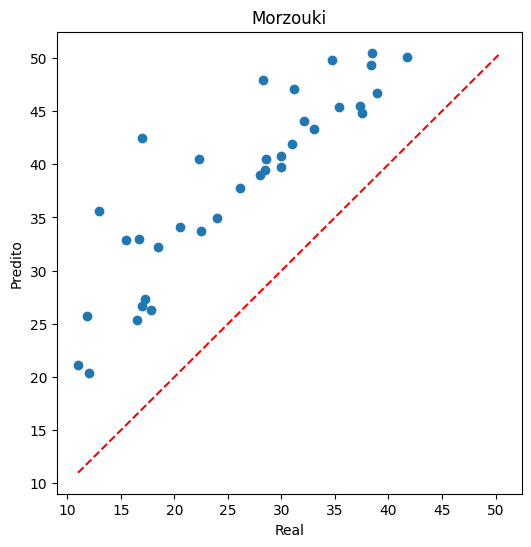

In [38]:
plt.figure(figsize=(6,6))

plt.scatter(
    grupo["y_true"],
    grupo["y_pred"]
)

mn = min(grupo["y_true"].min(), grupo["y_pred"].min())
mx = max(grupo["y_true"].max(), grupo["y_pred"].max())

plt.plot([mn,mx],[mn,mx],"r--")

plt.xlabel("Real")
plt.ylabel("Predito")
plt.title("Morzouki")
plt.show()

In [39]:
print(grupo.residual.mean())
print(grupo.residual.std())

-12.383600456376454
4.207680465234418


In [41]:
autor_stats = (
    debug_df
    .groupby("group")
    .agg(
        mae=("abs_error","mean"),
        bias=("residual","mean"),
        n=("y_true","size")
    )
    .sort_values("mae", ascending=False)
)

display(autor_stats)

,mae,bias,n
group,,,
A Morzouki 2016,12.383600,-12.383600,35
Md Jahidul Islam 2025,7.838333,-7.838333,12
"Guemmadi et al, 2009",6.834371,-4.068961,25
Feltrin 2018,6.160411,5.814940,27
"Abdul-Ghani et al, 2019",6.154047,4.523011,21
Sun e Chen 2018,6.152410,-0.754225,18
Ramezanianpour et al. (2009),5.925649,1.581583,48
Gyu Don Moon 2017,5.812184,5.812184,18
Meddah et al 2014,5.663757,-3.508878,136
